In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ipywidgets import interact, IntSlider
import numpy as np
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry, SamPredictor
from PIL import Image
import os
import pickle
import io
from sklearn.cluster import DBSCAN

import torch
import cv2

# Functions

In [3]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [4]:
def preprocess_image(file_path, max_file_size_kb=100, step=10, initial_quality=85):
    """
    Resize and compress the image to meet the file size requirement and return the image as a NumPy array.

    Args:
        file_path (str): Path to the input image file.
        max_file_size_kb (int): Maximum file size in kilobytes.
        step (int): Decrease in size percentage with each iteration.
        initial_quality (int): Starting compression quality.

    Returns:
        np.ndarray: Processed image as a NumPy array.
    """
    img = Image.open(file_path)
    if img.mode == 'P':  
        img = img.convert('RGB')
    img_format = 'JPEG'

    quality = initial_quality
    while True:
        img_byte_arr = io.BytesIO()
        img.save(img_byte_arr, format=img_format, quality=quality)
        size_kb = len(img_byte_arr.getvalue()) / 1024

        if size_kb <= max_file_size_kb:
            img_byte_arr.seek(0)
            img_final = Image.open(img_byte_arr)
            return np.array(img_final)

        if quality <= 10 or img.width < 50 or img.height < 50:
            raise ValueError("Cannot compress the image below the desired size without excessive quality loss or dimension reduction.")

        new_width = int(img.width * ((100 - step) / 100))
        new_height = int(img.height * ((100 - step) / 100))
        img = img.resize((new_width, new_height), Image.LANCZOS)
        quality = max(10, quality - 5)

In [11]:
def filtering(sorted_masks, eps_values, min_samples_values):
    """
    Filters the identified masks by clustering their areas using DBSCAN.

    This function systematically runs DBSCAN over a grid of parameters (eps_values, min_samples_values),
    identifies the largest cluster for each combination, and tracks which largest cluster (as a set of
    mask indices) occurs most frequently.

    Parameters
    ----------
    sorted_masks : list of dict
        Each dict should have at least the key 'area', e.g., mask['area'].
    eps_values : list or array-like
        Values of eps to try in DBSCAN.
    min_samples_values : list or array-like
        Values of min_samples to try in DBSCAN.

    Returns
    -------
    chosen_filtered_masks : list of dict
        The masks corresponding to the most commonly occurring largest cluster.
    chosen_params : tuple
        The (eps, min_samples) pair that produced this largest cluster.
    """

    # Prepare mask areas for clustering
    mask_areas = np.array([mask['area'] for mask in sorted_masks]).reshape(-1, 1)

    # Dictionary to track frequency of each "largest cluster" set
    cluster_frequency = {}

    # Iterate over all eps and min_samples values
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            clusters = dbscan.fit_predict(mask_areas)

            # Identify largest cluster label (exclude noise = -1)
            unique_clusters = np.unique(clusters)
            largest_cluster_label = None
            largest_cluster_size = -1
            for c in unique_clusters:
                if c == -1:
                    continue
                size_c = np.sum(clusters == c)
                if size_c > largest_cluster_size:
                    largest_cluster_size = size_c
                    largest_cluster_label = c

            # Handle cases with no valid clusters
            if largest_cluster_label is None:
                continue

            # Get indices of the largest cluster
            indices_in_largest_cluster = {
                idx for idx, clbl in enumerate(clusters) if clbl == largest_cluster_label
            }
            cluster_key = frozenset(indices_in_largest_cluster)

            # Update frequency dictionary
            if cluster_key not in cluster_frequency:
                cluster_frequency[cluster_key] = {
                    'count': 0,
                    'params': []
                }
            cluster_frequency[cluster_key]['count'] += 1
            cluster_frequency[cluster_key]['params'].append((eps, min_samples))

    if not cluster_frequency:
        print("No non-noise clusters found for any parameter combination.")
        return [], (None, None)

    # Find the most frequent largest cluster
    max_count = 0
    most_common_cluster_key = None
    for c_key, info in cluster_frequency.items():
        if info['count'] > max_count:
            max_count = info['count']
            most_common_cluster_key = c_key

    most_common_cluster_info = cluster_frequency[most_common_cluster_key]
    chosen_params = most_common_cluster_info['params'][0]

    # Build the final list of filtered masks
    most_common_indices = list(most_common_cluster_key)
    chosen_filtered_masks = [sorted_masks[i] for i in most_common_indices]

    # Print cluster size and chosen parameters
    total_masks = len(sorted_masks)
    chosen_count = len(chosen_filtered_masks)
    print(
        f"Most common largest cluster size: {chosen_count} "
        f"out of {total_masks} total masks.\n"
        f"Chosen parameters: eps={chosen_params[0]}, min_samples={chosen_params[1]}"
    )

    return chosen_filtered_masks, chosen_params

In [14]:
def automatic_identification(image_path, compress=False, apply_filtering=False, eps_values=None, min_samples_values=None, **kwargs):
    """
    Perform automatic mask identification on an input image using the SAM model.

    Args:
        image_path (str): Path to the input image file.
        compress (bool): Whether to compress the image before processing.
        filtering (bool): Whether to filter masks using the filtering function.
        eps_values (list or array-like): Values of eps to try in DBSCAN for filtering.
        min_samples_values (list or array-like): Values of min_samples to try in DBSCAN for filtering.
        **kwargs: Optional parameters to configure the SAM model. Supported keys include:
            - points_per_side (int): Number of points per side for mask generation.
            - pred_iou_thresh (float): IOU threshold for mask prediction.
            - stability_score_thresh (float): Stability score threshold for mask filtering.
            - min_mask_region_area (int): Minimum area of a mask to be considered.
            - output_mode (str): Output mode for the masks (e.g., 'binary_mask').
            - device (str): Device to run the model on ('cpu' or 'cuda').

    Returns:
        list: A list of generated masks sorted by area, with each mask containing its properties like bbox and area.
    """
    # Default parameters
    default_params = {
        'points_per_side': 32,
        'pred_iou_thresh': 0.9,
        'stability_score_thresh': 0.95,
        'min_mask_region_area': 500,
        'output_mode': 'binary_mask',
        'device': 'cpu'
    }

    # Default filtering parameters
    if eps_values is None:
        eps_values = np.linspace(100, 1200, 11)
    if min_samples_values is None:
        min_samples_values = range(1, 5)
    
    # Override default parameters with user-provided ones
    params = {**default_params, **kwargs}

    # Load and optionally preprocess the image
    if compress:
        print("Compressing the image...")
        image = preprocess_image(image_path)
        print("Image is compressed.")
    else:
        image = np.array(Image.open(image_path))

    # Cache file for storing generated masks
    cache_file = f"{os.path.splitext(image_path)[0]}_masks.pkl"

    # Check if masks have already been generated for this image
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            sorted_masks = pickle.load(f)
        print("Loaded cached masks.")
    else:
        # Initialize the SAM model
        print("Initializing SAM model...")
        model_type = "vit_h"
        checkpoint = "../models/sam_vit_h_4b8939.pth"  # Update with your checkpoint path
        sam = sam_model_registry[model_type](checkpoint)
        sam.to(device=params['device'])
        print("SAM model was initialized successfully.")

        # Initialize mask generator with SAM
        mask_generator = SamAutomaticMaskGenerator(
            model=sam,
            points_per_side=params['points_per_side'],
            pred_iou_thresh=params['pred_iou_thresh'],
            stability_score_thresh=params['stability_score_thresh'],
            min_mask_region_area=params['min_mask_region_area'],
            output_mode=params['output_mode']
        )

        # Generate masks
        print("Generating masks...")
        generated_masks = mask_generator.generate(image)
        print("Masks were generated.")

        # Sort masks by area
        sorted_masks = sorted(generated_masks, key=lambda x: x['area'], reverse=True)
        
        # Save masks to cache
        with open(cache_file, 'wb') as f:
            pickle.dump(sorted_masks, f)
        print("Generated and cached masks.")

    # Optionally filter masks
    if apply_filtering:
        print("Filtering masks...")
        sorted_masks, chosen_params = filtering(sorted_masks, eps_values, min_samples_values)
        print(f"Filtering completed with chosen parameters: {chosen_params}")

    sorted_mask_ids = {id(mask): idx for idx, mask in enumerate(sorted_masks)}

    def plot_masks(ax, masks, edge_color):
        for mask in masks:
            bbox = mask['bbox']  # Assuming bbox is [x_min, y_min, width, height]
            rect = Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1, edgecolor=edge_color, facecolor='none')
            ax.add_patch(rect)
            mask_id = sorted_mask_ids[id(mask)]
            ax.text(bbox[0] + bbox[2] / 2, bbox[1] + bbox[3] / 2, f"{mask_id}",
                    color='yellow', ha='center', va='center', fontsize=8,
                    bbox=dict(facecolor='black', alpha=0.5))

    def display_mask(index):
        sorted_by_area = sorted(sorted_masks, key=lambda x: x['area'])
        mask = sorted_by_area[index]
        bbox = mask['bbox']

        # Create a subplot for the mask
        fig, ax = plt.subplots(figsize=(5, 5))

        # Display the image
        ax.imshow(image, cmap='gray')
        ax.set_title(f'Mask ID: {sorted_mask_ids[id(mask)]}\nArea: {mask["area"]} pixels')

        # Draw the bounding box for the mask
        rect = Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Zoom into the mask area
        ax.set_xlim([bbox[0], bbox[0] + bbox[2]])
        ax.set_ylim([bbox[1] + bbox[3], bbox[1]])

        plt.show()

    # Plot the first figure: image with masks
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image, cmap='gray')
    ax.set_title('Image with Identified Masks' if not filtering else 'Image with Filtered Masks')
    plot_masks(ax, sorted_masks, 'blue')
    plt.show()

    # Interactive slider for browsing masks
    interact(display_mask, index=IntSlider(min=0, max=len(sorted_masks) - 1, step=1, value=0))

    return sorted_masks

Compressing the image...
Image is compressed.
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 95 out of 136 total masks.
Chosen parameters: eps=100.0, min_samples=1
Filtering completed with chosen parameters: (100.0, 1)


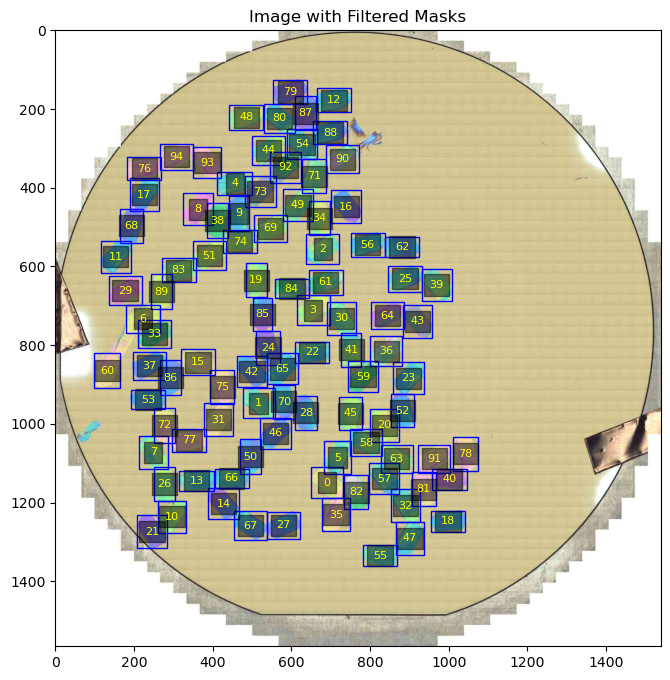

interactive(children=(IntSlider(value=0, description='index', max=94), Output()), _dom_classes=('widget-intera…

In [17]:
masks = automatic_identification("../images/wafer6_250nm_95sections_0.08mm-s_RGB copy.png", compress=True, apply_filtering=True)

# Implementation

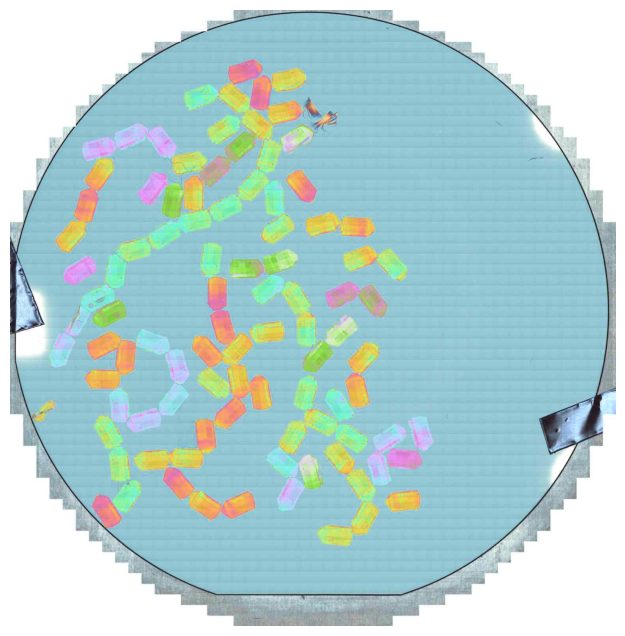

In [9]:
# upload, compress, and display image

filepath = "../images/wafer6_250nm_95sections_0.08mm-s_RGB copy.png"
filename = cv2.imread(filepath)
image = preprocess_image(filepath) # compressing the image
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('off')
plt.show()

In [118]:
# setting up model

model_type = "vit_h"
checkpoint = "../models/sam_vit_h_4b8939.pth"

sam = sam_model_registry[model_type](checkpoint)
sam.to(device="cpu")

predictor = SamPredictor(sam)
predictor.set_image(image)


Area Distribution (Histogram) of Generated Masks:
Area range 300 - 399: 1 masks, IDs: [0]
Area range 500 - 599: 1 masks, IDs: [1]
Area range 800 - 899: 2 masks, IDs: [2, 3]
Area range 1100 - 1199: 1 masks, IDs: [4]
Area range 1400 - 1499: 1 masks, IDs: [5]
Area range 1500 - 1599: 2 masks, IDs: [6, 7]
Area range 1600 - 1699: 1 masks, IDs: [8]
Area range 2200 - 2299: 1 masks, IDs: [9]
Area range 2500 - 2599: 1 masks, IDs: [10]
Area range 3600 - 3699: 2 masks, IDs: [11, 12]
Area range 3700 - 3799: 18 masks, IDs: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Area range 3800 - 3899: 35 masks, IDs: [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
Area range 3900 - 3999: 37 masks, IDs: [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102]
Area range 4000 - 4099: 3 masks, IDs: [1

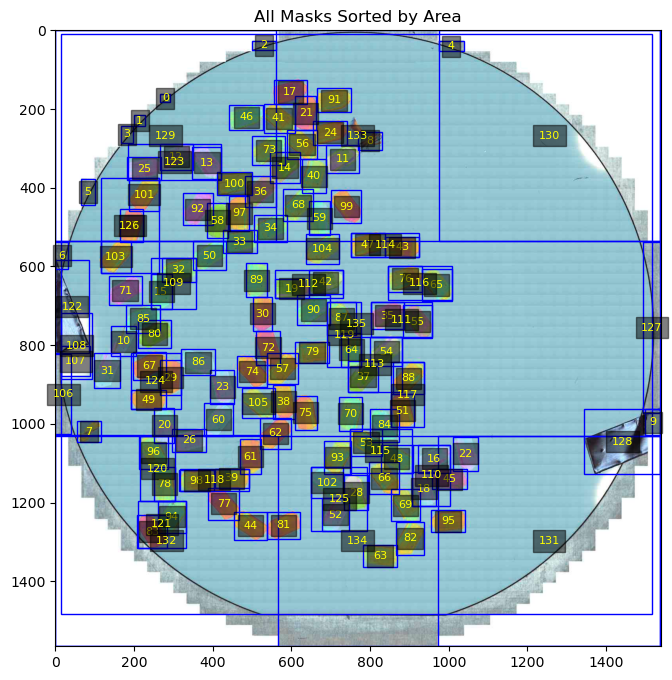

In [119]:
from matplotlib.patches import Rectangle

# Set generic parameters for the model
params = {
    'points_per_side': 32,
    'pred_iou_thresh': 0.9,
    'stability_score_thresh': 0.95,
    'min_mask_region_area': 500,  # Consider adjusting based on expected smallest area
    'output_mode': 'binary_mask'
}

# Initialize the model with selected parameters
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=params['points_per_side'],
    pred_iou_thresh=params['pred_iou_thresh'],
    stability_score_thresh=params['stability_score_thresh'],
    min_mask_region_area=params['min_mask_region_area'],
    output_mode=params['output_mode']
)

# Generate masks
generated_masks = mask_generator.generate(image)

# Sorting masks by area
sorted_masks = sorted(generated_masks, key=lambda x: x['area'])
sorted_mask_ids = {id(mask): idx for idx, mask in enumerate(sorted_masks)}

# Extract areas for the histogram
mask_areas = [mask['area'] for mask in sorted_masks]

# Generating and printing histogram of mask areas
area_bins = np.arange(0, max(mask_areas) + 100, 100)
hist, bins = np.histogram(mask_areas, bins=area_bins)
print("\nArea Distribution (Histogram) of Generated Masks:")
for i in range(len(hist)):
    if hist[i] > 0:
        bin_mask_ids = [sorted_mask_ids[id(sorted_masks[j])] for j in range(len(mask_areas)) if bins[i] <= mask_areas[j] < bins[i + 1]]
        print(f"Area range {bins[i]} - {bins[i + 1] - 1}: {hist[i]} masks, IDs: {bin_mask_ids}")

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust the size as needed
ax.imshow(image, cmap='gray')
ax.set_title('All Masks Sorted by Area')

def plot_masks(ax, masks, edge_color):
    for mask in masks:
        rect = Rectangle((mask['bbox'][0], mask['bbox'][1]), mask['bbox'][2], mask['bbox'][3],
                         linewidth=1, edgecolor=edge_color, facecolor='none')
        ax.add_patch(rect)
        # Annotate the mask ID
        mask_id = sorted_mask_ids[id(mask)]
        ax.text(mask['bbox'][0] + mask['bbox'][2] / 2, mask['bbox'][1] + mask['bbox'][3] / 2, str(mask_id),
                color='yellow', ha='center', va='center', fontsize=8, bbox=dict(facecolor='black', alpha=0.5))

plot_masks(ax, sorted_masks, 'blue')  # Plot all masks

plt.show()

Image Size: 6.90 MB
Model Size: 2445.57 MB


,Image Size (MB),Model Size (MB),Peak Memory Usage (MB),Average Runtime per Image (s),Total Runtime (s),CPU Utilization (%),Memory Utilization (%),Scalability Analysis,Parameters
0,6.895414,2445.566589,647.08407,212.407652,1062.053635,73.98,59.58,"{'Image Sizes': [256, 512, 1024, 2048], 'Runti...","(650.0, 3)"


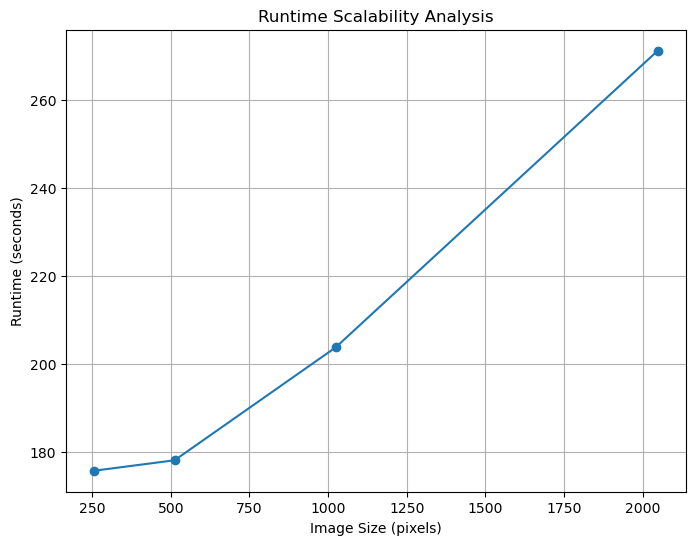

In [145]:
import psutil
import tracemalloc
import time
import matplotlib.pyplot as plt

def robust_assessment(image, mask_generator, sam_model, params, batch_size=1):
    """
    A robust assessment of technical specifications for the segmentation process.

    Args:
    - image (np.ndarray): The input image.
    - mask_generator (SamAutomaticMaskGenerator): The mask generator instance.
    - sam_model (torch.nn.Module): The SAM model instance.
    - params (dict): Parameters used for mask generation.
    - batch_size (int): Number of images processed in one batch.

    Returns:
    - dict: Dictionary containing detailed technical metrics.
    """
    # Measure image size
    image_size_mb = sys.getsizeof(image) / (1024 ** 2)  # Convert bytes to MB
    print(f"Image Size: {image_size_mb:.2f} MB")
    
    # Measure model size
    model_size_mb = sum(p.numel() for p in sam_model.parameters()) * 4 / (1024 ** 2)  # Float32
    print(f"Model Size: {model_size_mb:.2f} MB")
    
    # CPU and memory usage tracking
    cpu_utilization = []
    mem_utilization = []
    tracemalloc.start()

    # Record start time
    total_start_time = time.time()

    # Mask generation
    batch_runtime = []
    for _ in range(batch_size):
        start_time = time.time()
        generated_masks = mask_generator.generate(image)
        end_time = time.time()
        batch_runtime.append(end_time - start_time)
        cpu_utilization.append(psutil.cpu_percent(interval=None))
        mem_utilization.append(psutil.virtual_memory().percent)

    # Record end time
    total_end_time = time.time()
    total_runtime = total_end_time - total_start_time

    # Peak memory usage
    peak_memory_mb = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
    tracemalloc.stop()

    # Average runtime per image
    avg_runtime = sum(batch_runtime) / len(batch_runtime)

    # Scalability analysis
    image_sizes = [256, 512, 1024, 2048]
    runtime_scaling = []
    for size in image_sizes:
        resized_image = cv2.resize(image, (size, size), interpolation=cv2.INTER_LINEAR)
        start_time = time.time()
        mask_generator.generate(resized_image)
        end_time = time.time()
        runtime_scaling.append(end_time - start_time)

    # Output results
    results = {
        "Image Size (MB)": image_size_mb,
        "Model Size (MB)": model_size_mb,
        "Peak Memory Usage (MB)": peak_memory_mb,
        "Average Runtime per Image (s)": avg_runtime,
        "Total Runtime (s)": total_runtime,
        "CPU Utilization (%)": sum(cpu_utilization) / len(cpu_utilization),
        "Memory Utilization (%)": sum(mem_utilization) / len(mem_utilization),
        "Scalability Analysis": {
            "Image Sizes": image_sizes,
            "Runtimes (s)": runtime_scaling,
        },
        "Parameters": params,
    }
    
    return results

# Run the robust assessment
results = robust_assessment(image=image, mask_generator=mask_generator, sam_model=sam, params=params, batch_size=5)

# Display results
import pandas as pd
results_df = pd.DataFrame([results])
display(results_df)

# Plot scalability analysis
plt.figure(figsize=(8, 6))
plt.plot(results["Scalability Analysis"]["Image Sizes"], results["Scalability Analysis"]["Runtimes (s)"], marker='o')
plt.xlabel('Image Size (pixels)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime Scalability Analysis')
plt.grid(True)
plt.show()

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ipywidgets import interact, IntSlider
import numpy as np

# Assume 'image' is loaded, and 'sorted_masks' are generated and have 'bbox' attributes
def display_mask(index):
    mask = sorted_masks[index]
    bbox = mask['bbox']  # Assuming bbox is [x_min, y_min, width, height]
    
    # Create a subplot with specified size
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Display image
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Mask ID: {sorted_mask_ids[id(mask)]}')
    
    # Add a rectangle for the mask
    rect = Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=1, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Zoom into the mask area
    ax.set_xlim([bbox[0], bbox[0] + bbox[2]])
    ax.set_ylim([bbox[1] + bbox[3], bbox[1]])
    
    plt.show()

# Create a slider to browse through masks
interact(display_mask, index=IntSlider(min=0, max=len(sorted_masks)-1, step=1, value=0))

NameError: name 'sorted_masks' is not defined

# Filtering

'Yes a section' IDs: {10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105}
Processed eps=100.00, min_samples=1, Score: 0.99
Included IDs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
Missing IDs: [10]
Processed eps=100.00, min_samples=2, Score: 0.99
Included IDs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 

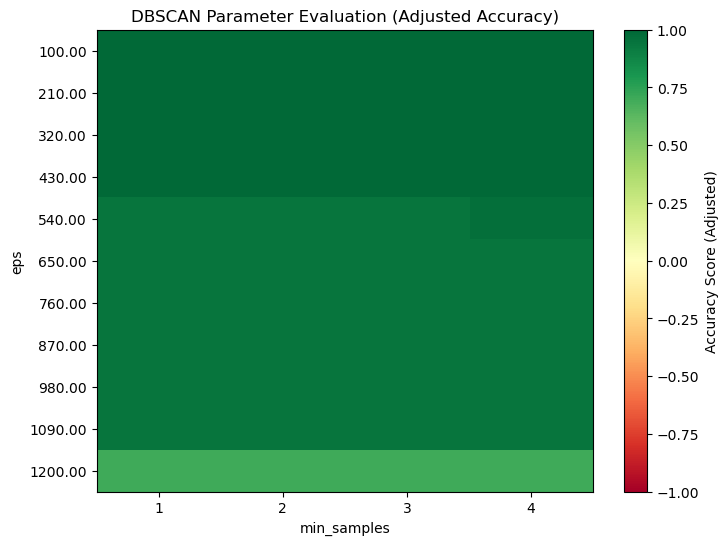

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap

# Ground truth data
not_a_section_ids = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135}
yes_a_section_ids = set(range(135)) - not_a_section_ids
print(f"'Yes a section' IDs: {yes_a_section_ids}")

# Parameter ranges
eps_values = np.linspace(100, 1200, 11)
min_samples_values = range(1,5)

# Store results
results = np.zeros((len(eps_values), len(min_samples_values)))

# Make sure mask_areas is reshaped correctly
mask_areas = np.array([mask['area'] for mask in sorted_masks]).reshape(-1, 1)

# Iterate over each combination of eps and min_samples
for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        # Run DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(mask_areas)
        
        # Determine the largest cluster
        cluster_ids = np.unique(clusters)
        largest_cluster = max(cluster_ids, key=lambda x: (clusters == x).sum() if x != -1 else -1)
        
        # Extract IDs in the largest cluster
        ids_in_cluster = {idx for idx, cluster in enumerate(clusters) if cluster == largest_cluster}
        
        # Calculate the accuracy adjustment
        true_positives = len(ids_in_cluster & yes_a_section_ids)
        false_positives = len(ids_in_cluster & not_a_section_ids)
        total_correct = len(yes_a_section_ids)
        
        if total_correct > 0:
            accuracy_score = true_positives / total_correct - false_positives / len(not_a_section_ids)
        else:
            accuracy_score = 0
        
        results[i, j] = accuracy_score

        # Print progress and partial results
        included_ids = sorted(ids_in_cluster)
        excluded_ids = sorted(yes_a_section_ids - ids_in_cluster)
        print(f"Processed eps={eps:.2f}, min_samples={min_samples}, Score: {accuracy_score:.2f}")
        print(f"Included IDs: {included_ids}")
        print(f"Missing IDs: {excluded_ids}")

# Create a color map from red to green
cmap = plt.get_cmap("RdYlGn")

plt.figure(figsize=(8, 6))
plt.imshow(results, cmap=cmap, interpolation='none', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Accuracy Score (Adjusted)')
plt.xticks(ticks=np.arange(len(min_samples_values)), labels=min_samples_values)
plt.yticks(ticks=np.arange(len(eps_values)), labels=[f"{eps:.2f}" for eps in eps_values])
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.title('DBSCAN Parameter Evaluation (Adjusted Accuracy)')

plt.show()


In [133]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets

# Assuming 'sorted_masks' is already defined and sorted by area
mask_areas = np.array([mask['area'] for mask in sorted_masks if mask['area'] <= 20000])
mask_ids = np.array([idx for idx, mask in enumerate(sorted_masks) if mask['area'] <= 20000])

# Ground truth data
not_section_ids = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135}
yes_section_ids = set(range(135)) - not_a_section_ids
print(f"'Yes a section' IDs: {yes_section_ids}")

def plot_dbscan(eps, min_samples):
    # Run DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(mask_areas.reshape(-1, 1))
    
    # Plot
    plt.figure(figsize=(12, 6))
    unique_clusters = np.unique(clusters)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_clusters)))

    for cluster_id, color in zip(unique_clusters, colors):
        ids_in_cluster = mask_ids[clusters == cluster_id]
        areas_in_cluster = mask_areas[clusters == cluster_id]
        
        # Plot each section
        for idx, area in zip(ids_in_cluster, areas_in_cluster):
            shape = 'o' if idx in yes_section_ids else '^'
            plt.scatter(idx, area, color=color if cluster_id != -1 else 'gray',s=50, marker=shape, edgecolor='black', label=f'Cluster {cluster_id}')
    
    plt.title(f'DBSCAN Clustering with eps={eps} and min_samples={min_samples}')
    plt.xlabel('Mask ID')
    plt.ylabel('Area')
    plt.grid(True)
    plt.ylim([0, max(mask_areas)+1000])
    plt.xlim([0, len(sorted_masks)])
    plt.show()

# Widgets for interaction
eps_slider = FloatSlider(min=100, max=1200, step=100, value=500, description='eps:')
min_samples_slider = IntSlider(min=1, max=10, step=1, value=2, description='min_samples:')

interact(plot_dbscan, eps=eps_slider, min_samples=min_samples_slider)


'Yes a section' IDs: {10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105}


interactive(children=(FloatSlider(value=500.0, description='eps:', max=1200.0, min=100.0, step=100.0), IntSlid…

<function __main__.plot_dbscan(eps, min_samples)>

Statistics of Filtered Mask Areas:
Mean area: 3875.79
Median area: 3885.00
Standard deviation of area: 80.96
Minimum area: 3676
Maximum area: 4093
Total masks: 95

Area Distribution (Histogram) of Filtered Masks:
Area range 3600 - 3699: 2 masks, IDs: [11, 12]
Area range 3700 - 3799: 18 masks, IDs: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Area range 3800 - 3899: 35 masks, IDs: [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
Area range 3900 - 3999: 37 masks, IDs: [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102]
Area range 4000 - 4099: 3 masks, IDs: [103, 104, 105]


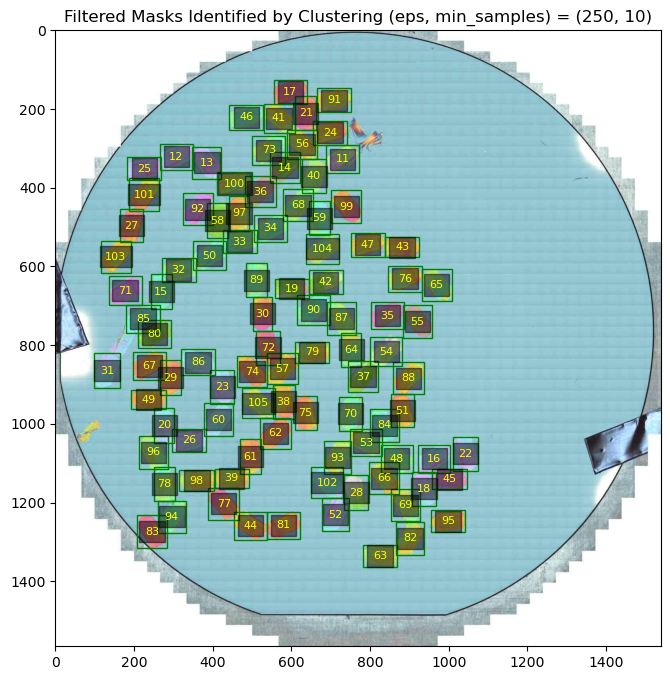

In [79]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Assume generated_masks already contains all mask data
mask_areas = np.array([mask['area'] for mask in sorted_masks]).reshape(-1, 1)

# Parameters
eps = 250
min_samples = 10

# Applying DBSCAN to find clusters based on area
dbscan = DBSCAN(eps=eps, min_samples=min_samples)  # Adjust these values based on further observations
clusters = dbscan.fit_predict(mask_areas)

# Identify the largest cluster (excluding noise, which is labeled as -1)
cluster_ids = np.unique(clusters)
largest_cluster = max(cluster_ids, key=lambda x: (clusters == x).sum() if x != -1 else -1)

# Filter masks that are within the largest cluster
filtered_masks = [mask for i, mask in enumerate(sorted_masks) if clusters[i] == largest_cluster]
filtered_mask_areas = [mask['area'] for mask in filtered_masks]
filtered_mask_ids = [sorted_mask_ids[id(mask)] for mask in filtered_masks]

# Calculating statistics for filtered mask areas
mean_area = np.mean(filtered_mask_areas)
median_area = np.median(filtered_mask_areas)
std_dev_area = np.std(filtered_mask_areas)
min_area = np.min(filtered_mask_areas)
max_area = np.max(filtered_mask_areas)

# Print the statistics of the filtered mask areas
print("Statistics of Filtered Mask Areas:")
print(f"Mean area: {mean_area:.2f}")
print(f"Median area: {median_area:.2f}")
print(f"Standard deviation of area: {std_dev_area:.2f}")
print(f"Minimum area: {min_area}")
print(f"Maximum area: {max_area}")
print(f"Total masks: {len(filtered_mask_areas)}")

# Generating and printing histogram of filtered mask areas
area_bins = np.arange(0, max_area + 100, 100)
hist, bins = np.histogram(filtered_mask_areas, bins=area_bins)
print("\nArea Distribution (Histogram) of Filtered Masks:")
for i in range(len(hist)):
    if hist[i] > 0:
        bin_mask_ids = [filtered_mask_ids[j] for j in range(len(filtered_mask_areas)) if bins[i] <= filtered_mask_areas[j] < bins[i + 1]]
        print(f"Area range {bins[i]} - {bins[i + 1] - 1}: {hist[i]} masks, IDs: {bin_mask_ids}")

# Plotting the filtered results
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image, cmap='gray')
ax.set_title(f'Filtered Masks Identified by Clustering (eps, min_samples) = ({eps}, {min_samples})')

for mask in filtered_masks:
    rect = Rectangle((mask['bbox'][0], mask['bbox'][1]), mask['bbox'][2], mask['bbox'][3],
                     linewidth=1, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    mask_id = sorted_mask_ids[id(mask)]
    ax.text(mask['bbox'][0] + mask['bbox'][2] / 2, mask['bbox'][1] + mask['bbox'][3] / 2, str(mask_id),
            color='yellow', ha='center', va='center', fontsize=8, bbox=dict(facecolor='black', alpha=0.5))

plt.show()

In [7]:
masks = automatic_identification("../images/wafer6_250nm_95sections_0.08mm-s_RGB copy.png", compress=True, filtering=True)

Compressing the image...
Image is compressed.
Loaded cached masks.


ValueError: Filtering requires eps_values and min_samples_values to be provided.